In [4]:
"""
Script de traitement des données de limites planétaires (LP)
Génère un graphique en barres empilées représentant les LP par sous-processus
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

In [134]:
# ============================================================================
# 1. PARAMÈTRES GLOBAUX
# ============================================================================

BASE_DIR = r"C:\Users\Arnaud\Documents\PlaneFR\data"
EXT_DIR = r"C:\Users\Arnaud\Documents\PlaneFR\data\base-year_2015\extensions"
THRESHOLD_PARAM = "Egalité"  # Peut être changé à "capacité" ou autre

# Paths des fichiers source
FACTEURS_CARAC_FILE = Path(BASE_DIR) / "facteurs de caractérisation.xlsx"
BRIDGE_MATRICES_FILE = Path(BASE_DIR) / "bridge_matrices.xlsx"
SEUILS_FILE = Path(BASE_DIR) / "seuils.xlsx"

# Couleurs pour les 5 catégories de consommation
CATEGORY_COLORS = {
    0: "#1f77b4",  # Bleu
    1: "#ff7f0e",  # Orange
    2: "#2ca02c",  # Vert
    3: "#d62728",  # Rouge
    4: "#9467bd"   # Violet
}

# Fonctions utilitaires pour générer les nuances
def get_dark_shade(hex_color, factor=0.7):
    """Retourne une nuance foncée d'une couleur hex"""
    h = hex_color.lstrip('#')
    rgb = tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
    dark_rgb = tuple(int(c * factor) for c in rgb)
    return '#{:02x}{:02x}{:02x}'.format(*dark_rgb)

def get_light_shade(hex_color, factor=1.3):
    """Retourne une nuance claire d'une couleur hex"""
    h = hex_color.lstrip('#')
    rgb = tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
    light_rgb = tuple(min(255, int(c * factor)) for c in rgb)
    return '#{:02x}{:02x}{:02x}'.format(*light_rgb)


In [70]:
# ============================================================================
# 2. FONCTIONS DE CHARGEMENT DES DONNÉES
# ============================================================================

def load_facteurs_carac():
    """
    Charge le fichier des facteurs de caractérisation.
    
    Returns:
        pd.DataFrame: DataFrame contenant les colonnes:
            - "Sous-processus"
            - "processus du système Terre" (LP)
            - "extensions exiobase"
            - "facteur de caractérisation"
    """
    print("Chargement des facteurs de caractérisation...")
    df = pd.read_excel(FACTEURS_CARAC_FILE)
    print(f"  ✓ {len(df)} lignes chargées")
    return df


def load_bridge_matrices():
    """
    Charge la matrice bridge "Final conso. cat".
    
    Returns:
        pd.DataFrame: Matrice contenant les catégories de consommation
    """
    print("Chargement de la matrice bridge...")
    df = pd.read_excel(BRIDGE_MATRICES_FILE, sheet_name="Final conso. cat.")
    print(f"  ✓ Matrice de shape {df.shape}")
    return df


def load_seuils():
    """
    Charge le fichier des seuils.
    
    Returns:
        pd.DataFrame: DataFrame "synthèse" contenant:
            - Index: noms des LP (et lignes spéciales comme "nom LP", "correspondances", THRESHOLD_PARAM)
            - Colonnes: sous-processus
    """
    print("Chargement des seuils...")
    df = pd.read_excel(SEUILS_FILE, sheet_name="Synthèse", index_col=0)
    print(f"  ✓ {len(df)} lignes chargées")
    return df


def load_d_cba(lp_name, origin="imp"):
    """
    Charge un fichier d_cba (demandes finales).
    
    Args:
        lp_name (str): Nom du processus du système Terre (ex: "Eau", "Énergie")
        origin (str): "imp" pour importé, "dom" pour domestique
    
    Returns:
        pd.DataFrame: DataFrame des demandes finales
    """
    if origin == "imp":
        folder_name = f"imp_{lp_name}"
    else:
        folder_name = f"dom_{lp_name}"
    
    file_path = Path(EXT_DIR) / folder_name / "d_cba_k.pkl"
    
    if not file_path.exists():
        print(f"  ⚠ Fichier non trouvé: {file_path}")
        return None
    
    df = pd.read_pickle(file_path)
    return df

In [113]:
# ============================================================================
# 3. FONCTIONS DE TRAITEMENT DES DONNÉES
# ============================================================================

def get_unique_subprocesses(facteurs_carac_df):
    """
    Extrait les sous-processus uniques et crée un mapping vers les LP.
    
    Args:
        facteurs_carac_df (pd.DataFrame): DataFrame des facteurs
    
    Returns:
        dict: Dictionnaire {sous-processus: LP}
    """
    subprocess_to_lp = {}
    for _, row in facteurs_carac_df.iterrows():
        subprocess = row["Sous-processus"]
        lp = row["Processus du système Terre"]
        if subprocess not in subprocess_to_lp:
            subprocess_to_lp[subprocess] = lp
    
    return subprocess_to_lp


def process_single_subprocess(subprocess_name, lp_name, facteurs_carac_df, 
                             bridge_matrices_df, seuils_df):
    """
    Traite un sous-processus spécifique:
    1. Charge les données d_cba (imports et domestiques)
    2. Filtre par les extensions associées
    3. Applique les facteurs de caractérisation
    4. Agrège avec la matrice bridge
    
    Args:
        subprocess_name (str): Nom du sous-processus
        lp_name (str): Nom de la LP associée
        facteurs_carac_df (pd.DataFrame): DataFrame des facteurs
        bridge_matrices_df (pd.DataFrame): Matrice bridge
    
    Returns:
        dict: {
            'domestique': pd.Series (1x5),
            'importé': pd.Series (1x5),
            'categories': list des noms des catégories
        }
    """
    print(f"  Traitement: {subprocess_name} ({lp_name})")
    
    # Étape 1: Charger les fichiers d_cba
    d_cba_imp = load_d_cba(lp_name, origin="imp")
    d_cba_dom = load_d_cba(lp_name, origin="dom")
    
    if d_cba_imp is None or d_cba_dom is None:
        print(f"    ⚠ Données manquantes pour {lp_name}")
        return None
    
    # Étape 2: Récupérer les extensions associées à ce sous-processus
    mask = facteurs_carac_df["Sous-processus"] == subprocess_name
    subprocess_data = facteurs_carac_df[mask]
    
    # Colonne contenant les extensions et les facteurs
    extensions = subprocess_data["Extensions exiobase"].values
    factors = subprocess_data["Facteurs de caractérisation"].values
    
    # Étape 3: Créer un dictionnaire {extension: facteur}
    extension_factor_map = dict(zip(extensions, factors))
    
    # Étape 4: Filtrer et pondérer les données d_cba
    # On cherche les lignes dont l'index correspond aux extensions
    def filter_and_weight_dcba(d_cba_df, extension_factor_map):
        """Filtre les lignes et applique les pondérations"""
        weighted_rows = []

        for idx, row in d_cba_df.iterrows():
            # L'index peut être une tuple ou un MultiIndex
            # On extrait le premier élément si c'est une tuple
            idx_value = idx[0] if isinstance(idx, tuple) else idx
            
            # Vérifier si l'index (extension) est dans notre map
            if idx_value in extension_factor_map:
                factor = extension_factor_map[idx_value]
                weighted_rows.append(row * factor)
        
        if not weighted_rows:
            return pd.Series(dtype=float)
        
        # Somme des lignes pondérées
        summed = pd.DataFrame(weighted_rows).sum(axis=0)
        
        # Si les colonnes ont un MultiIndex, on prend le dernier niveau (les noms des secteurs)
        if isinstance(summed.index, pd.MultiIndex):
            # On prend le dernier niveau du MultiIndex comme nouveau index
            summed.index = summed.index.get_level_values(-1)
        
        return summed
    
    # Traiter les imports et domestiques séparément
    vector_imp = filter_and_weight_dcba(d_cba_imp, extension_factor_map)
    vector_dom = filter_and_weight_dcba(d_cba_dom, extension_factor_map)
    
    if vector_imp.empty or vector_dom.empty:
        print(f"    ⚠ Aucune donnée filtrée pour {subprocess_name}")
        return None
    
    # Étape 5: Multiplication matricielle avec la matrice bridge
    # Prendre les colonnes des catégories de consommation finale (à partir de la colonne 6)
    # Multiplier chaque colonne par le vecteur et sommer
    
    bridge_categories = bridge_matrices_df.iloc[1:, 6:]
    bridge_categories.index = bridge_matrices_df.iloc[1:, 5].values
    # Multiplication : pour chaque colonne (catégorie), on multiplie par vector_imp/vector_dom et on somme
    # Résultat : Series avec les noms des catégories comme index
    result_imp = bridge_categories.T @ vector_imp
    result_dom = bridge_categories.T @ vector_dom
    
    # Étape 6: Normalisation par la valeur de conversion
    # Diviser les résultats par la valeur à l'intersection de la ligne "Conversion" et la colonne du LP
    try:
        if "Conversion" in seuils_df.index and subprocess_name in seuils_df.columns:
            conversion_factor = seuils_df.loc["Conversion", subprocess_name]
            if conversion_factor != 0 and not pd.isna(conversion_factor):
                result_imp = result_imp / conversion_factor
                result_dom = result_dom / conversion_factor
            else:
                print(f"    ⚠ Facteur de conversion invalide pour {subprocess_name}")
        else:
            print(f"    ⚠ Valeur de conversion introuvable pour {subprocess_name}")
    except Exception as e:
        print(f"    ⚠ Erreur lors de la normalisation: {e}")
    
    return {
        'domestique': result_dom,
        'importé': result_imp,
        'categories': result_imp.index.tolist()
    }


In [143]:
# ============================================================================
# 4. FONCTION DE VISUALISATION
# ============================================================================

def create_stacked_bar_chart(data_by_subprocess, seuils_df, subprocess_to_lp):
    """
    Crée un graphique en barres empilées représentant les LP en pourcentages.
    
    Args:
        data_by_subprocess (dict): {subprocess_name: traitement_result}
        seuils_df (pd.DataFrame): DataFrame des seuils
        subprocess_to_lp (dict): Mapping subprocess -> LP
    """
    # Préparer les données pour le graphique
    subprocesses = list(data_by_subprocess.keys())
    n_subprocesses = len(subprocesses)
    
    # Récupérer les catégories (supposé identique pour tous)
    first_valid_data = None
    for data in data_by_subprocess.values():
        if data is not None:
            first_valid_data = data
            break
    
    if first_valid_data is None:
        print("⚠ Aucune donnée valide à visualiser")
        return
    
    categories = first_valid_data['categories']
    n_categories = len(categories)
    
    # Initialiser les données pour le graphique
    x_labels = [sp for sp in subprocesses]
    
    # Créer une figure
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Préparer les hauteurs cumulées pour chaque barre
    bar_width = 0.6
    x_pos = np.arange(n_subprocesses)
    
    bottom_heights = np.zeros(n_subprocesses)
    total_values = np.zeros(n_subprocesses)  # Stocker les valeurs totales absolues
    
    # Itérer sur les catégories et origines
    for cat_idx, category in enumerate(categories):
        # Part domestique
        heights_dom = []
        for sp in subprocesses:
            data = data_by_subprocess[sp]
            if data is not None and 'domestique' in data:
                heights_dom.append(data['domestique'].get(category, 0))
            else:
                heights_dom.append(0)
        
        heights_dom = np.array(heights_dom)
        
        # Part importée
        heights_imp = []
        for sp in subprocesses:
            data = data_by_subprocess[sp]
            if data is not None and 'importé' in data:
                heights_imp.append(data['importé'].get(category, 0))
            else:
                heights_imp.append(0)
        
        heights_imp = np.array(heights_imp)
        
        # Accumuler les valeurs totales (pour la normalisation)
        total_values += (heights_dom + heights_imp)
    
    # Réinitialiser bottom_heights pour construire le graphique normalisé
    bottom_heights = np.zeros(n_subprocesses)
    
    # Itérer de nouveau pour tracer les barres normalisées
    for cat_idx, category in enumerate(categories):
        # Part domestique
        heights_dom = []
        for sp in subprocesses:
            data = data_by_subprocess[sp]
            if data is not None and 'domestique' in data:
                heights_dom.append(data['domestique'].get(category, 0))
            else:
                heights_dom.append(0)
        
        heights_dom = np.array(heights_dom)
        # Normaliser en pourcentage
        heights_dom_pct = np.where(total_values > 0, (heights_dom / total_values) * 100, 0)
        
        color_dark = get_dark_shade(CATEGORY_COLORS[cat_idx % len(CATEGORY_COLORS)])
        
        ax.bar(x_pos, heights_dom_pct, bar_width, label=f"{category} - Domestique",
               bottom=bottom_heights, color=color_dark, edgecolor='white', linewidth=0.5)
        
        bottom_heights += heights_dom_pct
        
        # Part importée
        heights_imp = []
        for sp in subprocesses:
            data = data_by_subprocess[sp]
            if data is not None and 'importé' in data:
                heights_imp.append(data['importé'].get(category, 0))
            else:
                heights_imp.append(0)
        
        heights_imp = np.array(heights_imp)
        # Normaliser en pourcentage
        heights_imp_pct = np.where(total_values > 0, (heights_imp / total_values) * 100, 0)
        
        color_light = get_light_shade(CATEGORY_COLORS[cat_idx % len(CATEGORY_COLORS)])
        
        ax.bar(x_pos, heights_imp_pct, bar_width, label=f"{category} - Importé",
               bottom=bottom_heights, color=color_light, edgecolor='white', linewidth=0.5)
        
        bottom_heights += heights_imp_pct
    
    # Ajouter les valeurs totales (en gras) et le dépassement au-dessus de chaque barre
    for idx, total_val in enumerate(total_values):
        sp = subprocesses[idx]
        lp = subprocess_to_lp[sp]
        
        # Afficher le total en gras
        ax.text(idx, 102, f'{total_val:.0f}', ha='center', va='bottom', 
               fontweight='bold', fontsize=10)

        # Afficher le dépassement (overshoot/undershoot) sous le total
        try:
            if THRESHOLD_PARAM in seuils_df.index and sp in seuils_df.columns:
                threshold = seuils_df.loc[THRESHOLD_PARAM, sp]
                if threshold > 0:
                    # Calculer le pourcentage de dépassement
                    overshoot_pct = ((total_val - threshold) / threshold) * 100
                    
                    # Déterminer la couleur et le label
                    if overshoot_pct > 0:
                        color = 'red'
                        label_text = f'+{overshoot_pct:.0f}%'
                    else:
                        color = 'green'
                        label_text = f'{overshoot_pct:.0f}%'
                    
                    # Afficher le texte du dépassement
                    ax.text(idx, 98, label_text, ha='center', va='top', 
                           fontweight='bold', fontsize=9, color=color)
        except (KeyError, TypeError):
            pass
    
    # Mise en forme du graphique
    ax.set_xlabel('Limites planétaires', fontsize=12, fontweight='bold')
    ax.set_ylabel('Part de la consommation finale (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Limites planétaires par sous-processus\n(Critère équité: {THRESHOLD_PARAM})',
                fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylim(0, 110)  # Laisser de la place pour les valeurs au-dessus
    
    # Légende
    handles, labels = ax.get_legend_handles_labels()
    # Supprimer les doublons dans la légende
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', 
             bbox_to_anchor=(1.05, 1), fontsize=10)
    
    plt.tight_layout()
    return fig, ax

ANALYSE DES LIMITES PLANÉTAIRES

▶ Étape 1: Chargement des données sources
----------------------------------------------------------------------
Chargement des facteurs de caractérisation...
  ✓ 51 lignes chargées
Chargement de la matrice bridge...
  ✓ Matrice de shape (1001, 11)
Chargement des seuils...
  ✓ 13 lignes chargées

▶ Étape 2: Extraction des sous-processus
----------------------------------------------------------------------
  ✓ 7 sous-processus identifiés:
    - N → biogeochemical
    - P → biogeochemical
    - Eau → water
    - CO2 → ghg_emissions
    - GES → ghg_emissions
    - Sols → land_use
    - Energie → energy

▶ Étape 3: Traitement des sous-processus
----------------------------------------------------------------------
  Traitement: N (biogeochemical)
  Traitement: P (biogeochemical)
  Traitement: Eau (water)
  Traitement: CO2 (ghg_emissions)
  Traitement: GES (ghg_emissions)
  Traitement: Sols (land_use)
  Traitement: Energie (energy)

  ✓ 7/7 sous-processus t

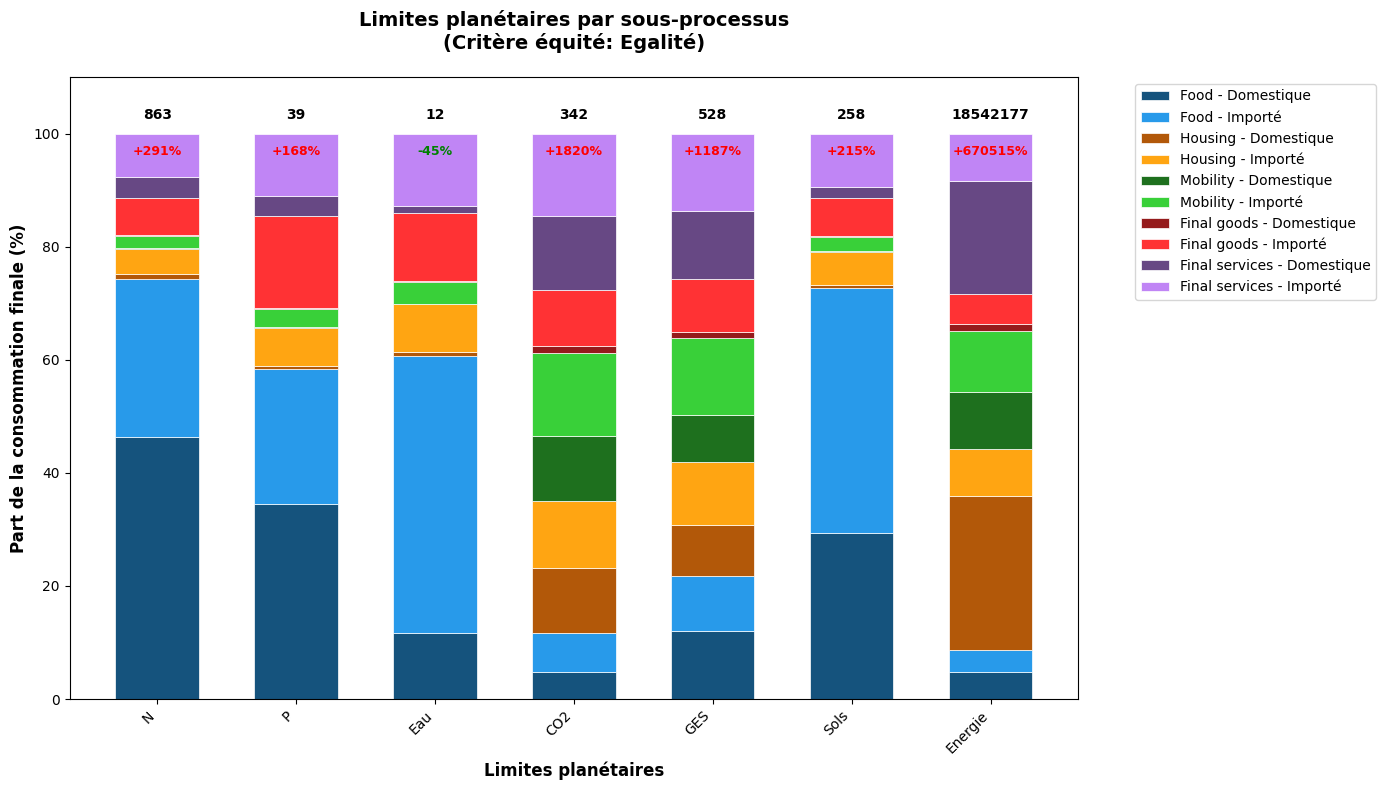


Analyse terminée avec succès !


In [144]:
# ============================================================================
# 5. FONCTION PRINCIPALE
# ============================================================================

def main():
    """Orchestration du script complet"""
    
    print("=" * 70)
    print("ANALYSE DES LIMITES PLANÉTAIRES")
    print("=" * 70)
    print()
    
    # Chargement des fichiers
    print("▶ Étape 1: Chargement des données sources")
    print("-" * 70)
    facteurs_carac_df = load_facteurs_carac()
    bridge_matrices_df = load_bridge_matrices()
    seuils_df = load_seuils()
    print()
    
    # Extraction des sous-processus
    print("▶ Étape 2: Extraction des sous-processus")
    print("-" * 70)
    subprocess_to_lp = get_unique_subprocesses(facteurs_carac_df)
    print(f"  ✓ {len(subprocess_to_lp)} sous-processus identifiés:")
    for sp, lp in subprocess_to_lp.items():
        print(f"    - {sp} → {lp}")
    print()
    
    # Traitement des données
    print("▶ Étape 3: Traitement des sous-processus")
    print("-" * 70)
    data_by_subprocess = {}
    for subprocess_name, lp_name in subprocess_to_lp.items():
        result = process_single_subprocess(subprocess_name, lp_name, 
                                          facteurs_carac_df, bridge_matrices_df, seuils_df)
        if result is not None:
            data_by_subprocess[subprocess_name] = result
    print()
    
    # Vérification
    print(f"  ✓ {len(data_by_subprocess)}/{len(subprocess_to_lp)} sous-processus traités avec succès")
    print()
    
    # Visualisation
    print("▶ Étape 4: Génération du graphique")
    print("-" * 70)
    if data_by_subprocess:
        fig, ax = create_stacked_bar_chart(data_by_subprocess, seuils_df, subprocess_to_lp)
        
        output_path = Path(BASE_DIR).parent / "planetary_boundaries_chart.png"
        fig.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ Graphique sauvegardé: {output_path}")
        
        plt.show()
    else:
        print("  ⚠ Aucune donnée à afficher")
    
    print()
    print("=" * 70)
    print("Analyse terminée avec succès !")
    print("=" * 70)


if __name__ == "__main__":
    main()
